# 02 - Eksperimen Baseline (Tugas 2)

Perbandingan terkontrol kontribusi fitur NLP terhadap baseline pasar:

| Model | Fitur |
|---|---|
| model0_market | fitur pasar (lag return, MA, volatilitas) |
| model1_market_sentiment | pasar + sentimen VADER & Loughran-McDonald |
| model2_market_tfidf | pasar + TF-IDF + SVD |
| model3_market_sentiment_tfidf | pasar + sentimen + TF-IDF |
| naive_all_up / naive_persistence | baseline naif (selalu naik / arah hari sebelumnya) |

**Protokol:** target `target_next_up` (arah kurs hari berikutnya, flat = 0); split kronologis train 2021-09..2024-12, validation 2025, test 2026; pemilihan konfigurasi (text source TF-IDF) hanya di validation; test dievaluasi sekali; `StandardScaler`, `TfidfVectorizer`, dan `TruncatedSVD` selalu di-fit di dalam pipeline pada data train.

In [1]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import config, data_preparation, evaluate, train

pd.set_option("display.max_columns", 50)
print("root:", ROOT)

root: C:\Users\Satya\Desktop\tugas 1 NLP\NLP-Project


## 1. Persiapan data dan split kronologis

`src.data_preparation.main()` melakukan audit, membangun target + fitur pasar + fitur sentimen, memverifikasi aturan leakage, lalu menulis `data/processed/train.csv`, `validation.csv`, `test.csv`.

In [2]:
frame = data_preparation.main()
fitur_pasar = pd.Series(config.MARKET_FEATURES, name="market_features")
print("fitur pasar:", ", ".join(config.MARKET_FEATURES))
print("fitur sentimen:", ", ".join(config.SENTIMENT_FEATURES))

audit dataset -> audit_summary.json
baris terbuang (histori < 20 hari atau label hari berikutnya tidak ada): 21
verifikasi leakage: lolos (fitur aman, split kronologis, cutoff berita benar)
     split  rows date_start   date_end  up_ratio
     train   790 2021-09-29 2024-12-31     0.562
validation   237 2025-01-02 2025-12-31     0.523
      test   154 2026-01-02 2026-08-31     0.571
dataset tersimpan: train.csv, validation.csv, test.csv
fitur pasar: ret_1d, ret_2d, ret_3d, ret_5d, rate_to_ma5, rate_to_ma20, vol_5, vol_20, log_rate
fitur sentimen: n_articles, vader_mean, vader_median, vader_std, vader_pos_ratio, vader_neg_ratio, vader_neutral_ratio, lm_polarity_mean, lm_polarity_median, lm_polarity_std, lm_pos_ratio, lm_neg_ratio, lm_neutral_ratio, lm_negative_mean, lm_positive_mean, lm_uncertainty_mean, lm_modal_mean


## 2. Pemilihan text source TF-IDF (validasi) dan pelatihan model

Tiga opsi teks dibandingkan pada validation memakai model3 (pasar + sentimen + TF-IDF): `title`, `body`, `title+body`. Konfigurasi terpilih dilatih untuk model0-model3, lalu diprediksi pada validation dan test.

In [3]:
text_source = train.main()
pd.read_csv(config.RESULTS_TEXT_SOURCE_CSV).round(4)

split: train 790 (2021-09-29..2024-12-31) | validation 237 (2025-01-02..2025-12-31) | test 154 (2026-01-02..2026-08-31)


pemilihan text source TF-IDF (validasi 2025, model3):
text_source  directional_accuracy  f1_up  f1_macro    mcc  roc_auc
 title+body                0.5232 0.5311    0.5231 0.0471   0.5124
      title                0.5359 0.6071    0.5201 0.0602   0.5328
       body                0.5190 0.5000    0.5183 0.0440   0.5114
text source terpilih untuk laporan akhir: title+body


ringkasan metrik validation (model0-model3; baseline naif dirujuk di laporan):
                        model   n  directional_accuracy  f1_up  f1_macro     mcc  roc_auc
                model0_market 237                0.5232 0.6319    0.4776  0.0252   0.5081
      model1_market_sentiment 237                0.4937 0.6129    0.4406 -0.0476   0.5094
          model2_market_tfidf 237                0.4726 0.4589    0.4722 -0.0506   0.4843
model3_market_sentiment_tfidf 237                0.5232 0.5311    0.5231  0.0471   0.5124
ringkasan metrik test (model0-model3; baseline naif dirujuk di laporan):
                        model   n  directional_accuracy  f1_up  f1_macro    mcc  roc_auc
                model0_market 154                0.5455 0.6354    0.5160 0.0440   0.5666
      model1_market_sentiment 154                0.5779 0.6948    0.5053 0.0863   0.5504
          model2_market_tfidf 154                0.5130 0.4526    0.5070 0.0845   0.5479
model3_market_sentiment_tfidf 154         

,text_source,directional_accuracy,f1_up,f1_macro,mcc,roc_auc
0,title+body,0.5232,0.5311,0.5231,0.0471,0.5124
1,title,0.5359,0.6071,0.5201,0.0602,0.5328
2,body,0.5190,0.5000,0.5183,0.0440,0.5114


## 3. Evaluasi pada validation dan test

Metrik utama: akurasi arah dan F1 (F1 kelas naik + F1 macro), ditambah ROC AUC, MCC, dan confusion matrix untuk interpretasi.

In [4]:
evaluate.main()
# Tabel fokus model0-model3; baris baseline naif tetap tersimpan di CSV.
validation_table = pd.read_csv(config.RESULTS_VALIDATION_CSV).round(4)
test_table = pd.read_csv(config.RESULTS_TEST_CSV).round(4)
print("== validation 2025 (model0-model3) ==")
display(validation_table[validation_table["model"].str.startswith("model")])
print("== test 2026 (model0-model3) ==")
display(test_table[test_table["model"].str.startswith("model")])

hasil validasi 2025 (model0-model3):
                        model   n  directional_accuracy  f1_up  f1_macro     mcc  roc_auc
                model0_market 237                0.5232 0.6319    0.4776  0.0252   0.5081
      model1_market_sentiment 237                0.4937 0.6129    0.4406 -0.0476   0.5094
          model2_market_tfidf 237                0.4726 0.4589    0.4722 -0.0506   0.4843
model3_market_sentiment_tfidf 237                0.5232 0.5311    0.5231  0.0471   0.5124
hasil test 2026 (model0-model3):
                        model   n  directional_accuracy  f1_up  f1_macro    mcc  roc_auc
                model0_market 154                0.5455 0.6354    0.5160 0.0440   0.5666
      model1_market_sentiment 154                0.5779 0.6948    0.5053 0.0863   0.5504
          model2_market_tfidf 154                0.5130 0.4526    0.5070 0.0845   0.5479
model3_market_sentiment_tfidf 154                0.5130 0.4526    0.5070 0.0845   0.5682


figure evaluasi -> C:\Users\Satya\Desktop\tugas 1 NLP\NLP-Project\reports\figures
tabel hasil -> results_validation.csv, results_test.csv
== validation 2025 (model0-model3) ==


,model,n,directional_accuracy,f1_up,f1_macro,mcc,roc_auc
0,model0_market,237,0.5232,0.6319,0.4776,0.0252,0.5081
1,model1_market_sentiment,237,0.4937,0.6129,0.4406,-0.0476,0.5094
2,model2_market_tfidf,237,0.4726,0.4589,0.4722,-0.0506,0.4843
3,model3_market_sentiment_tfidf,237,0.5232,0.5311,0.5231,0.0471,0.5124


== test 2026 (model0-model3) ==


,model,n,directional_accuracy,f1_up,f1_macro,mcc,roc_auc
0,model0_market,154,0.5455,0.6354,0.5160,0.0440,0.5666
1,model1_market_sentiment,154,0.5779,0.6948,0.5053,0.0863,0.5504
2,model2_market_tfidf,154,0.5130,0.4526,0.5070,0.0845,0.5479
3,model3_market_sentiment_tfidf,154,0.5130,0.4526,0.5070,0.0845,0.5682


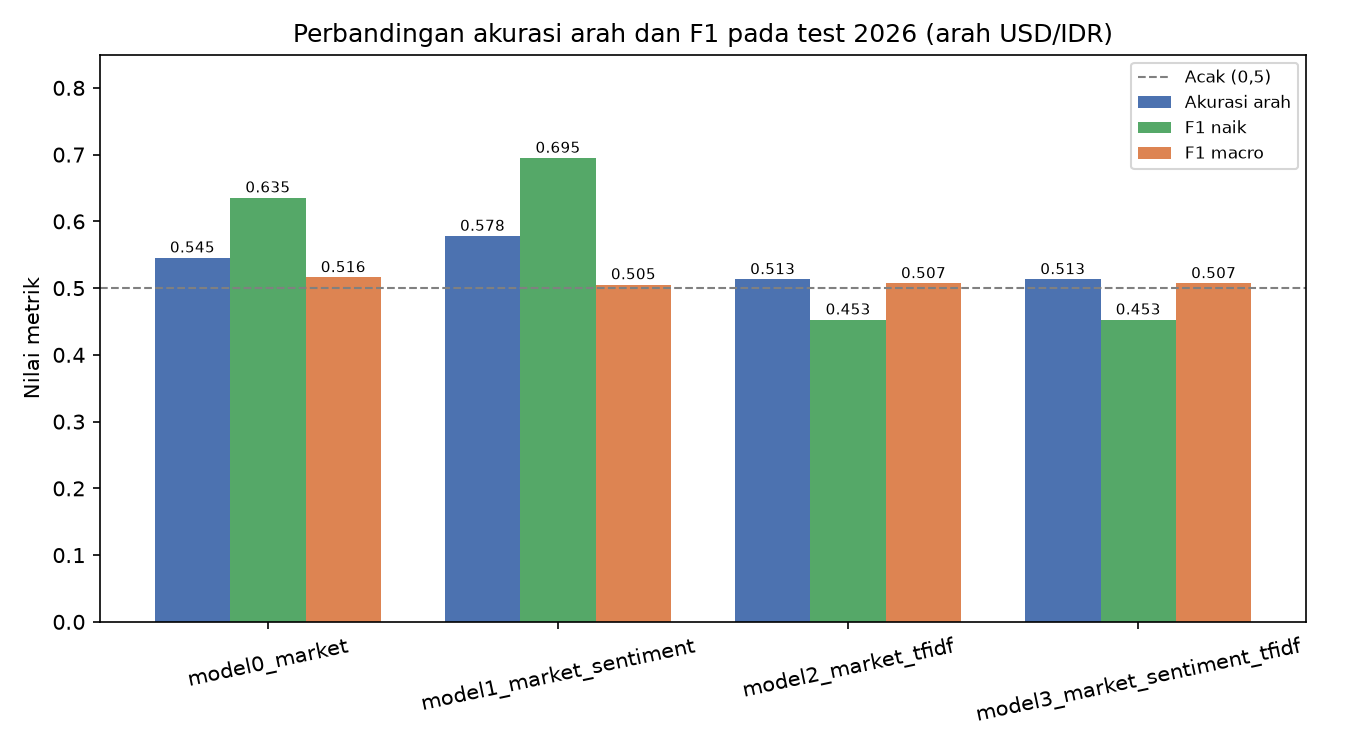

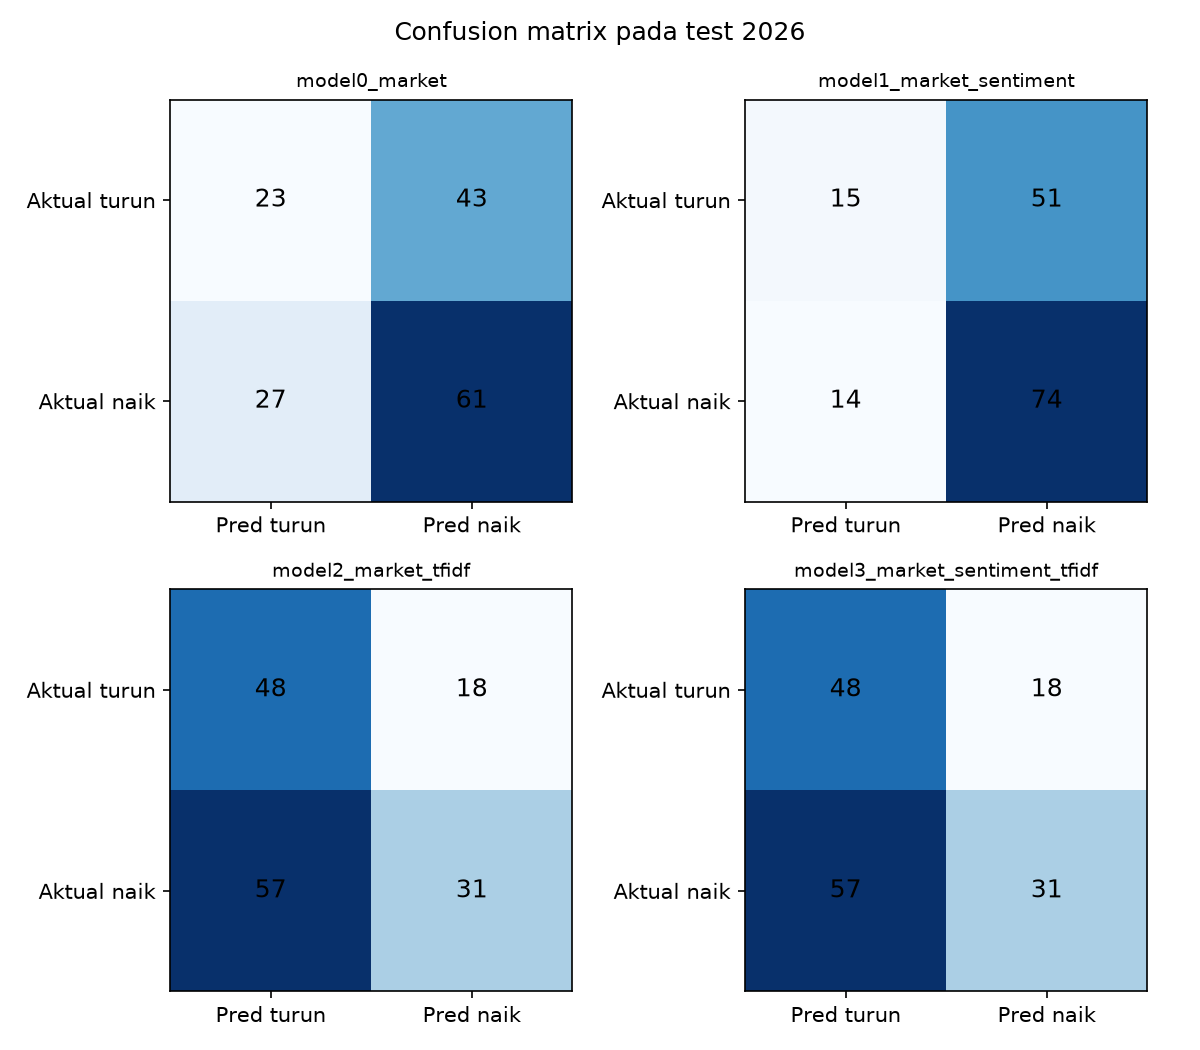

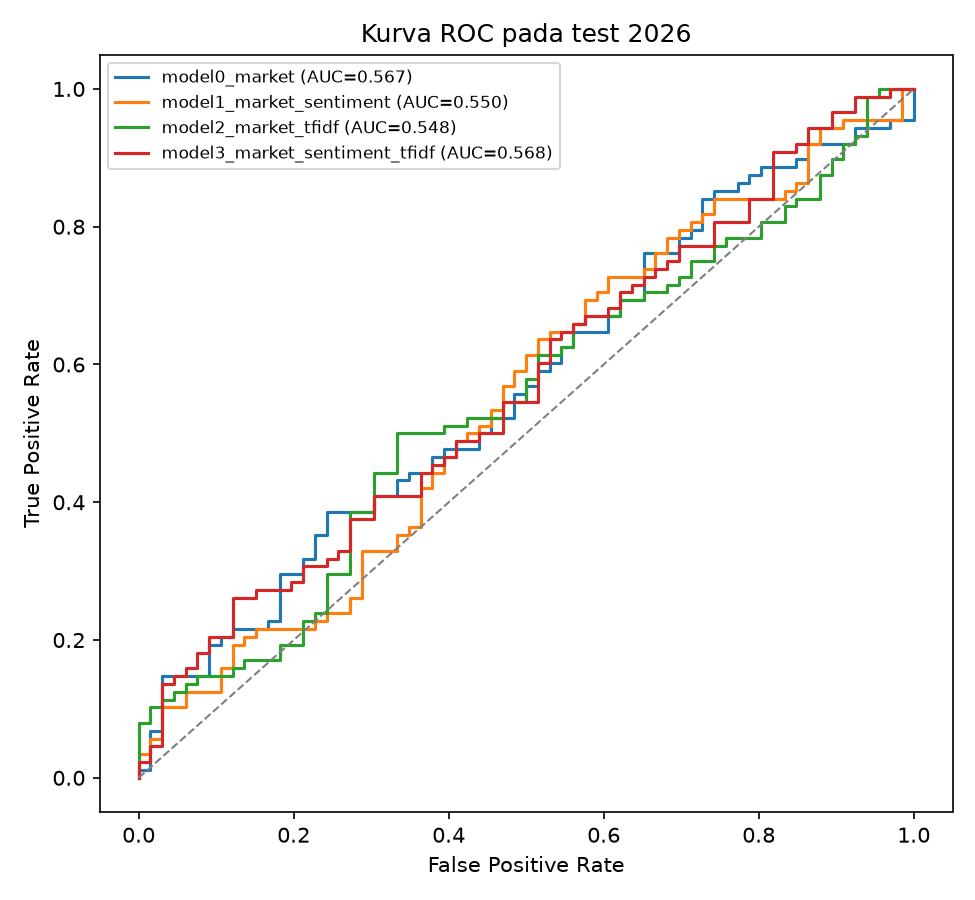

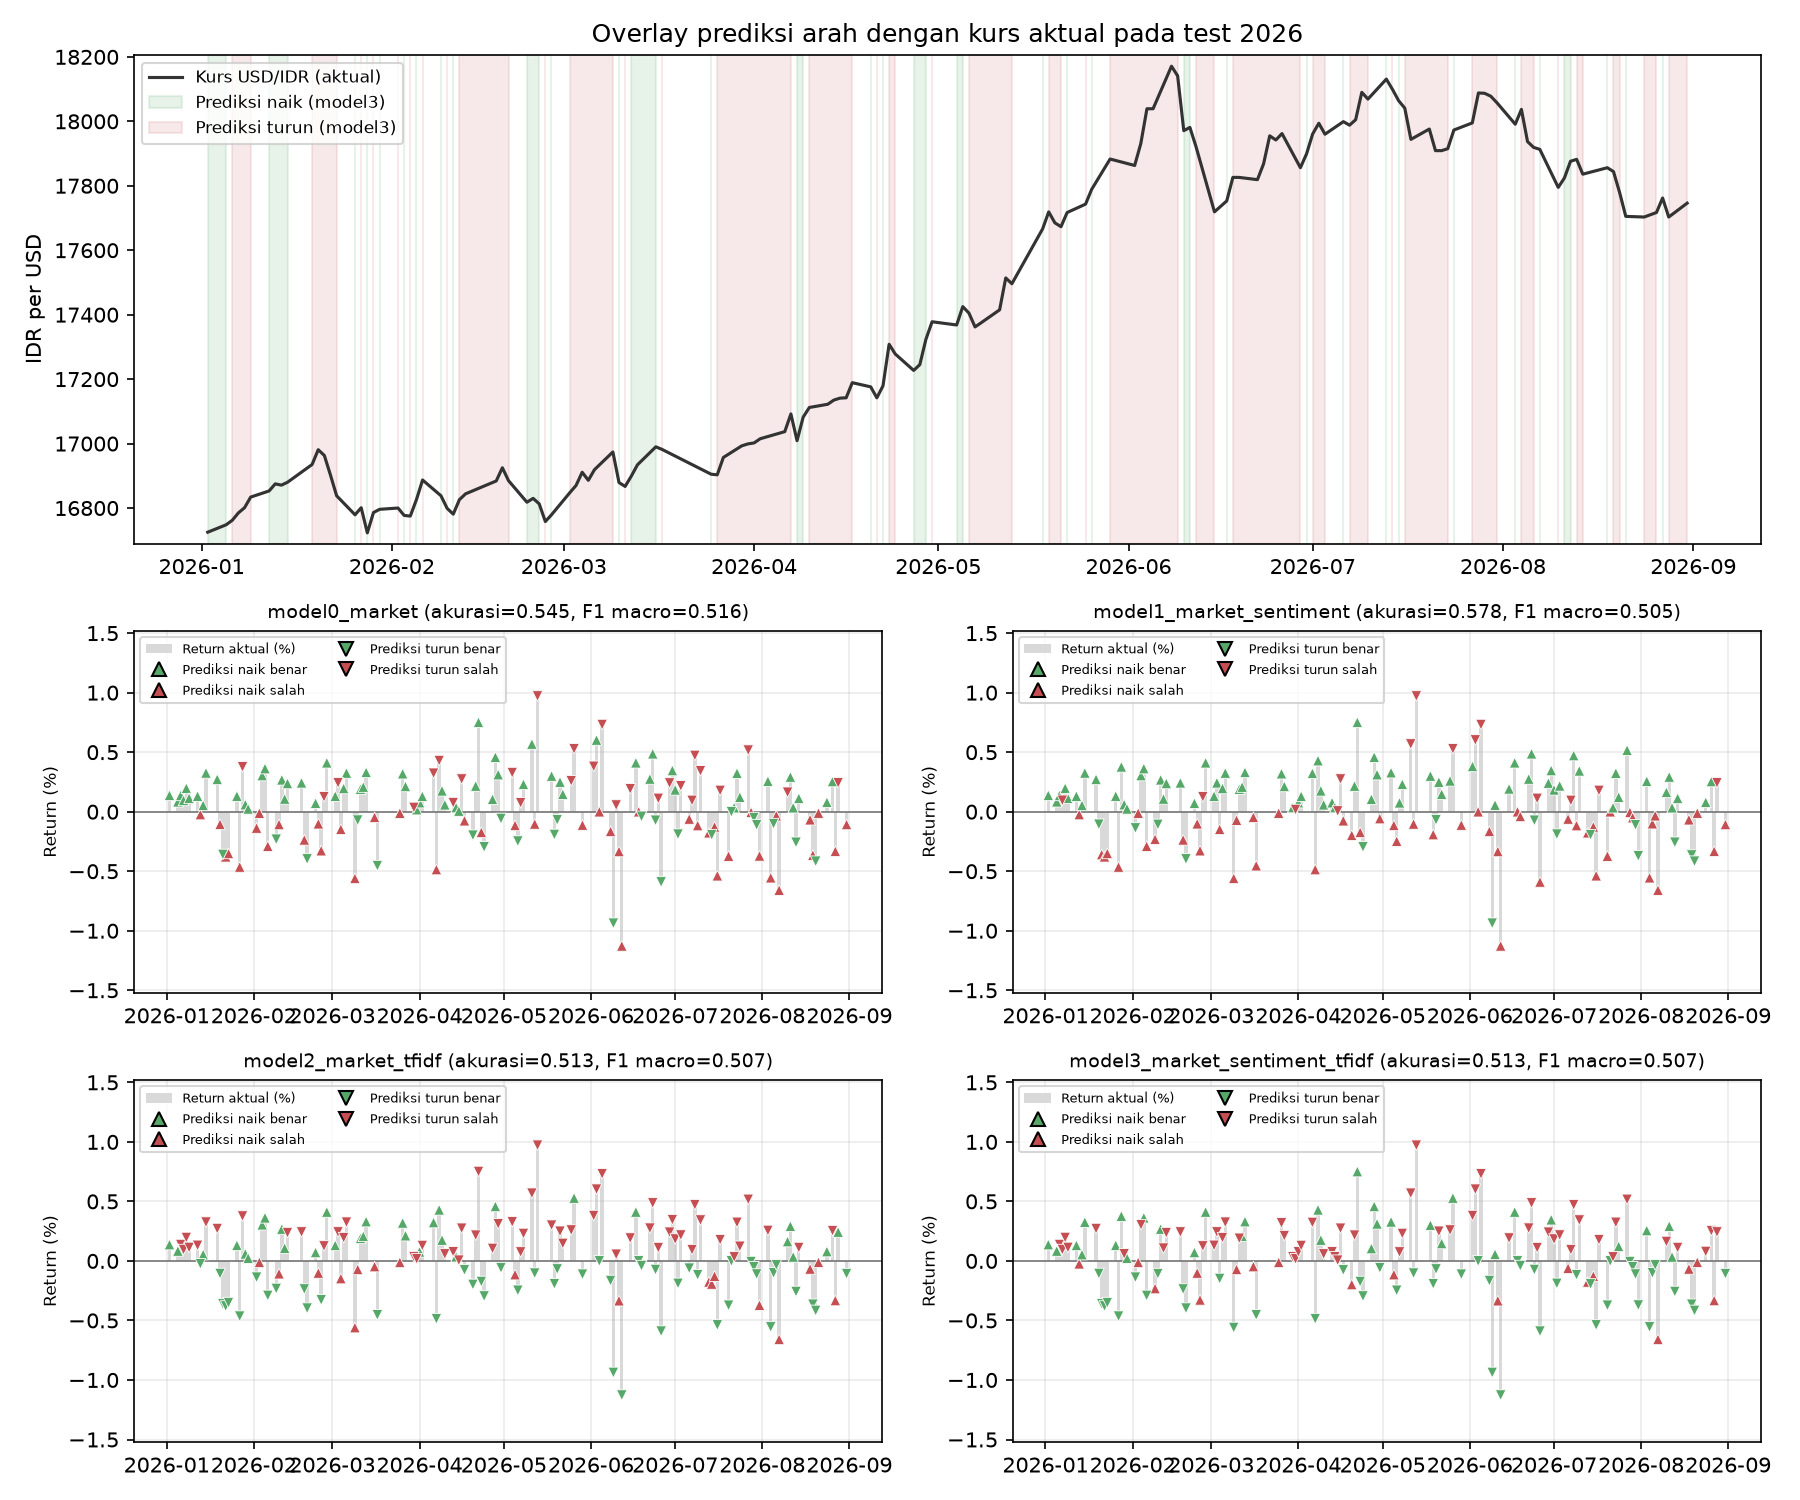

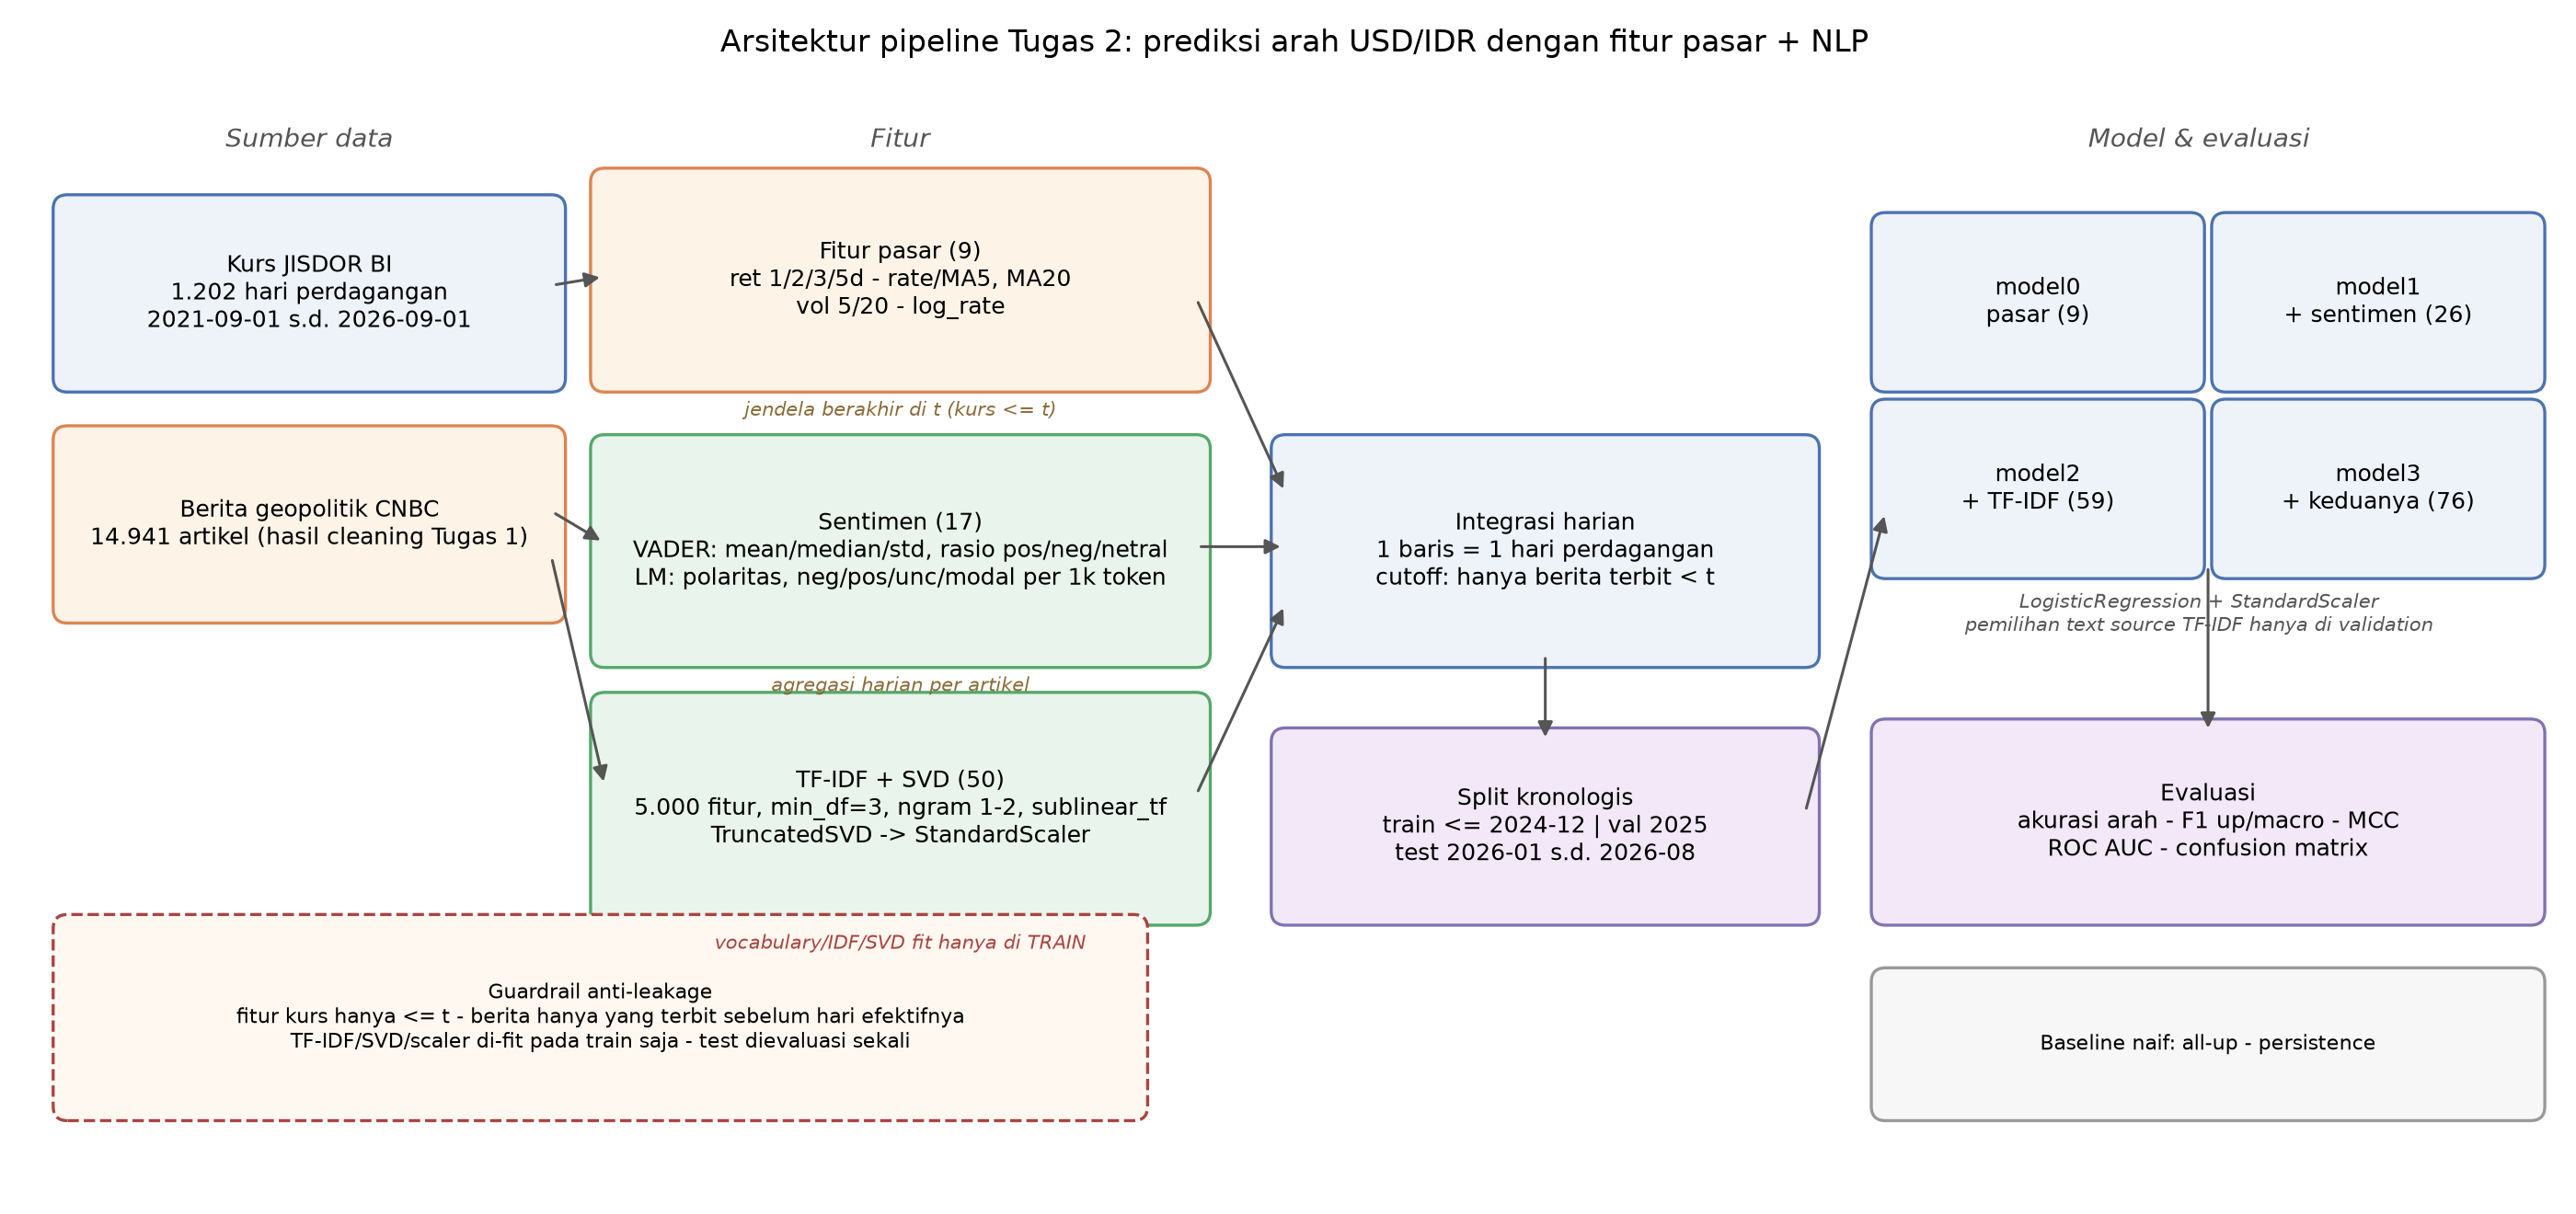

In [5]:
from IPython.display import Image, display

for figure in ["metrics_comparison_test.png", "confusion_matrix_test.png", "roc_test.png", "prediksi_vs_aktual_test.png", "pipeline_tugas2.png"]:
    display(Image(filename=str(config.FIGURES_DIR / figure)))

## 4. Analisis hasil (Phase 9)

1. **Market-only (model0):** test 2026 akurasi arah 54,6%, F1 macro 0,516, ROC AUC 0,567 — sedikit di atas acak tetapi akurasinya masih di bawah baseline selalu-naik (57,1%).
2. **Apakah sentimen mengubah performa?** Model1 memberi akurasi test terbaik (57,8%) dan F1 kelas naik 0,695, tetapi F1 macro turun (0,505) dan AUC turun ke 0,550; di validation justru akurasi 49,4%. Efeknya tidak stabil dan tidak konsisten antar-split.
3. **Apakah TF-IDF mengubah performa?** Model2 tidak menunjukkan perbaikan: test akurasi 51,3%, AUC 0,548, validation malah di bawah acak (0,484).
4. **Kombinasi sentimen + TF-IDF:** model3 memiliki AUC test tertinggi (0,568) tetapi akurasi 51,3% dan F1 macro 0,507 — tidak ada peningkatan yang meyakinkan dibanding model0.
5. **Overfitting/leakage/instabilitas:** peringkat model berubah antara validation dan test (mis. model1 terbaik di test tetapi terburuk di validation), selisih antar model kecil dibanding ukuran test (n=154), dan semua skor mendekati acak. Tidak ditemukan indikasi leakage (verifikasi cutoff dan split lolos), sehingga perbedaan yang terlihat lebih tepat dijelaskan sebagai derau, bukan sinyal NLP yang stabil.

Overlay prediksi vs kurs/return aktual (`reports/figures/prediksi_vs_aktual_test.png`) memperlihatkan model0/model1 condong memprediksi naik sehingga terlihat benar saat tren naik Mei-Juli 2026, sedangkan model2/model3 condong memprediksi turun; tidak ada model yang konsisten menangkap hari-hari pembalikan arah.

Catatan text source: `title+body` terpilih karena F1 macro validation tertinggi (0,5231 vs 0,5201 untuk `title`), tetapi `title` unggul pada akurasi (0,5359 vs 0,5232) dan AUC (0,5328 vs 0,5124). Selisih ini berada dalam kisaran derau; keputusan dicatat sebagai konfigurasi eksperimen, bukan klaim keunggulan.

Kesimpulan: pada setup klasikal ini (leksikon + TF-IDF + regresi logistik) belum ada bukti bahwa informasi berita geopolitik menambah sinyal prediktif yang stabil di luar fitur pasar. Ini menjawab pertanyaan riset secara negatif untuk baseline awal.

## 5. Konfigurasi eksperimen

```text
TARGET          = next_day_direction (flat = 0)
TEXT_SOURCE     = title+body (dipilih via validation)
SENTIMENT       = enabled (VADER + Loughran-McDonald)
TFIDF           = enabled (max_features=5000, min_df=3, ngram 1-2, SVD 50)
MODEL           = LogisticRegression (StandardScaler, max_iter=5000)
RANDOM_SEED     = 42
TRAIN_PERIOD    = 2021-09-29 s/d 2024-12-31 (790 baris)
VALIDATION      = 2025-01-02 s/d 2025-12-31 (237 baris)
TEST            = 2026-01-02 s/d 2026-08-31 (154 baris)
```

Reproduksi: `python -m src.data_preparation` -> `python -m src.train` -> `python -m src.evaluate`.